# Imports and opening the files

## 0. Library Imports

Import όλων των απαραίτητων βιβλιοθηκών για την ανάλυση:
- **Data manipulation:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **NLP:** `nltk`, `transformers`, `torch`
- **Utilities:** `os`, `sys`, `re`, `csv`, `openpyxl`, `tqdm`

In [ ]:
#libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os
import openpyxl
import csv
import sys
import re
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm


c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Newspaper Data

Φόρτωση των δύο CSV αρχείων (`Newspapers_1.csv`, `Newspapers_2.csv`) σε chunks για αποφυγή memory overflow.
- **`csv.field_size_limit`:** Αυξάνει το όριο μεγέθους πεδίου για μεγάλα άρθρα
- **`chunksize=500`:** Φόρτωση 500 γραμμών τη φορά για εξοικονόμηση μνήμης

In [2]:
csv.field_size_limit(10**7)

# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_1.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news1_df = pd.concat(results, ignore_index=True)

### 1b. Load Newspapers_2.csv

In [3]:
# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_2.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news2_df = pd.concat(results, ignore_index=True)

### 1c. Load Bond Spread Data

Φόρτωση του εβδομαδιαίου Greek-German bond spread (2010-2026) από Excel.

In [4]:
bonds_df = pd.read_excel(r"..\data\Greece_Germany_Bond_Spread_2010_2026.xlsx")

In [5]:
news1_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability


In [6]:
news2_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976812/stis-ar...,https://www.capital.gr/diethni/3976812/stis-ar...,143.0,success,NaN,2026-02-26 22:06,"Πέμπτη, 26-Φεβ-2026 22:06",ΔΙΕΘΝΗ,Στις αρχές Μαρτίου στα Εμιράτα η νέα τριμερής ...,Ο επόμενος γύρος των τριμερών ειρηνευτικών δια...,readability
1,https://www.capital.gr/agores/3976809/mikres-m...,https://www.capital.gr/agores/3976809/mikres-m...,282.0,success,NaN,2026-02-26 21:42,"Πέμπτη, 26-Φεβ-2026 21:42",ΑΓΟΡΕΣ,Μικρές μεταβολές ο χρυσός με το βλέμμα στις συ...,Οι τιμές του χρυσού παρέμειναν σχεδόν αμετάβλη...,readability
2,https://www.capital.gr/diethni/3976807/sunanti...,https://www.capital.gr/diethni/3976807/sunanti...,800.0,success,NaN,2026-02-26 21:33,"Πέμπτη, 26-Φεβ-2026 21:33",ΔΙΕΘΝΗ,"Μελόνι: ""Ιταλία και Κύπρος ανήκουν σε έναν...",Ο Κύπριος πρόεδρος Νίκος Χριστοδουλίδης είχε σ...,readability
3,https://www.capital.gr/diethni/3976805/sugkrou...,https://www.capital.gr/diethni/3976805/sugkrou...,224.0,success,NaN,2026-02-26 21:20,"Πέμπτη, 26-Φεβ-2026 21:20",ΔΙΕΘΝΗ,Συγκρούσεις στα σύνορα Πακιστάν - Αφγανιστάν,Οι αρχές των Ταλιμπάν δήλωσαν σήμερα ότι ο αφγ...,readability
4,https://www.capital.gr/diethni/3976801/ipa-ira...,https://www.capital.gr/diethni/3976801/ipa-ira...,220.0,success,NaN,2026-02-26 20:52,"Πέμπτη, 26-Φεβ-2026 20:52",ΔΙΕΘΝΗ,"Ολοκληρώθηκαν οι διαπραγματεύσεις με ""σημαντικ...",Οι διαπραγματεύσεις μεταξύ του Ιράν και των ΗΠ...,readability


In [7]:
bonds_df.head()

,Date,Spread
0,03/01/2026,0.7377
1,02/22/2026,0.6483
2,02/15/2026,0.6095
3,02/08/2026,0.6077
4,02/01/2026,0.6104


# Preprocessing

## 2. Data Preprocessing

### 2a. Combine Datasets & Compute Character Count

Συνένωση των δύο newspaper DataFrames σε ένα ενιαίο dataset και υπολογισμός του αριθμού χαρακτήρων ανά άρθρο ως πρώτο μέτρο μεγέθους.

In [8]:
# Combine both newspaper datasets
df = pd.concat([news1_df, news2_df], ignore_index=True)
# Compute char length
df["char_count"] = df['content'].str.len()

df = df.reset_index(drop=True)
print(f"Total articles: {len(df)}")
df.head()

Total articles: 1566371


,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method,char_count
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability,1003
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability,1978
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability,1800
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability,2015
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability,1266


### 2b. Drop Articles with Missing Category

Αφαίρεση άρθρων χωρίς κατηγορία (`heading_type = NaN`). Αυτά αντιστοιχούν σε ~369K άρθρα χωρίς metadata που δεν μπορούν να ταξινομηθούν.

In [9]:
before = len(df)
df = df.dropna(subset=["heading_type"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows with missing heading_type. Remaining: {len(df):,}")

Dropped 369,298 rows with missing heading_type. Remaining: 1,197,073


### 2c. Missing Value Audit

Έλεγχος για missing values σε όλες τις στήλες μετά το dropna, για να επιβεβαιωθεί η ποιότητα του dataset.

In [10]:
# Check for missing values across all columns
print("=" * 35)
print(f"{'Column':<20} {'NaN Count':>10}")
print("=" * 35)
for col in df.columns:
    print(f"{col:<20} {df[col].isna().sum():>10}")
print("=" * 35)


Column                NaN Count
original_url                  0
final_url                     0
word_count                27446
status                        0
error                   1197073
date                          0
date_raw                  27446
heading_type                  0
article_title                 0
content                       0
extraction_method             0
char_count                    0


### 2d. Heading Type Distribution

Εμφάνιση της κατανομής των κατηγοριών άρθρων για να εντοπιστούν οι irrelevant categories (lifestyle, health, sports κ.λπ.) που θα αφαιρεθούν στο επόμενο βήμα.

In [17]:
# Distribution of heading types
counts = df["heading_type"].value_counts()
print(f"Total unique heading types: {len(counts)}")
print("=" * 40)
print(f"{'Heading Type':<25} {'Count':>10}")
print("=" * 40)
for heading, count in counts.head(80).items():
    print(f"{heading:<25} {count:>10}")
print("=" * 40)


Total unique heading types: 164
Heading Type                   Count
ΔΙΕΘΝΗ                        230510
ΕΠΙΚΑΙΡΟΤΗΤΑ                  221847
VIDEO_NEWS                    177551
ΟΙΚΟΝΟΜΙΑ                     141472
ΕΠΙΧΕΙΡΗΣΕΙΣ                  113014
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ             96891
ΠΟΛΙΤΙΚΗ                       68609
ΑΓΟΡΕΣ                         53309
CAPITALHEALTH                   7201
BRAND VOICE                     5804
ΜΕ ΑΠΟΨΗ                        5782
ΑΡΘΡΑ                           5106
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ            4906
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ                  4749
FOREX                           4566
CAPITALTV                       4010
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ       3077
BLOOMBERG OPINION               2967
ΠΑΡΟΥΣΙΑΣΕΙΣ                    2864
ΤΕΧΝΟΛΟΓΙΑ                      2541
ΕΡΕΥΝΕΣ                         2123
REAL ESTATE - ΕΙΔΗΣΕΙΣ          1882
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ       1710
CAPITALTECH: INTERNET           1702
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ           1650
THINK

### 2e. Drop Irrelevant Columns

Αφαίρεση στηλών που δεν χρησιμοποιούνται στην ανάλυση για εξοικονόμηση μνήμης:
- `original_url`, `final_url`: URLs άρθρων
- `status`, `error`: Metadata crawling
- `date_raw`: Ακατέργαστη ημερομηνία (αντικαθίσταται από `date`)
- `extraction_method`: Τεχνικό metadata

In [12]:
df = df.drop(columns=['original_url', 'final_url', 'status', 'error', 'date_raw', 'extraction_method'])

In [13]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,2026-02-26 22:20,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,2026-02-26 21:58,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,2026-02-26 21:39,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,2026-02-26 21:28,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,2026-02-26 20:58,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


In [18]:
patterns = df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))
print(patterns.value_counts().to_string())

date
####-##-## ##:##       1169628
####-##-## ##:##:##      27417
####-##-##                  28


### 2f. Date Format Audit

Εντοπισμός όλων των διαφορετικών formats που εμφανίζονται στη στήλη `date`, αντικαθιστώντας τα ψηφία με `#` για να αναδειχθεί η δομή κάθε pattern. Αναμένουμε 3 valid formats:
- `####-##-## ##:##` → π.χ. `2024-03-15 14:30`
- `####-##-## ##:##:##` → π.χ. `2006-06-20 15:47:00`
- `####-##-##` → π.χ. `2006-05-08`

In [19]:
for pattern, group in df.groupby(df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))):
    print(f"{pattern}  →  {group['date'].iloc[0]}")

####-##-##  →  2006-05-08
####-##-## ##:##  →  2026-02-26 22:20
####-##-## ##:##:##  →  2006-06-20 15:47:00


In [ ]:
# Drop malformed
#mask_bad = df['date'].astype(str).str.match(r'^\d{2}:\d{4}/\d{2}')
#df = df[~mask_bad].reset_index(drop=True)

# Keep only first 10 chars (YYYY-MM-DD)
df['date'] = df['date'].astype(str).str[:10]

There cannot be a date where tehre is 1 and not 01 because the whole date would be less character and with a check we would catch them, since its zero, tehre isnt a value. 

### 2g. Date Component Validation

Επαλήθευση ότι οι ημερομηνίες δεν περιέχουν αδύνατες τιμές (π.χ. μήνας > 12, μέρα > 31) που θα υποδήλωναν parsing errors ή hallucinating values στο dataset.

In [22]:
# Validate date components for hallucinating values
date_parts = df['date'].astype(str).str.extract(r'(\d{2})/(\d{2})/(\d{4})')
date_parts.columns = ['month', 'day', 'year']
date_parts = date_parts.astype(float)

print("Date Component Validation")
print("=" * 40)
print(f"{'Year':<10} min: {date_parts['year'].min():.0f}   max: {date_parts['year'].max():.0f}")
print(f"{'Month':<10} min: {date_parts['month'].min():.0f}   max: {date_parts['month'].max():.0f}   (valid: 1-12)")
print(f"{'Day':<10} min: {date_parts['day'].min():.0f}   max: {date_parts['day'].max():.0f}   (valid: 1-31)")
print("=" * 40)
print(f"{'Month > 12:':<20} {(date_parts['month'] > 12).sum():>10}")
print(f"{'Day > 31:':<20} {(date_parts['day'] > 31).sum():>10}")
print(f"{'Month == 0:':<20} {(date_parts['month'] == 0).sum():>10}")
print(f"{'Day == 0:':<20} {(date_parts['day'] == 0).sum():>10}")
print("=" * 40)


Date Component Validation
Year       min: nan   max: nan
Month      min: nan   max: nan   (valid: 1-12)
Day        min: nan   max: nan   (valid: 1-31)
Month > 12:                   0
Day > 31:                     0
Month == 0:                   0
Day == 0:                     0


### 2h. Malformed Date Check

Έλεγχος για ημερομηνίες με λιγότερους από 10 χαρακτήρες (το minimum για format `YYYY-MM-DD`), οι οποίες υποδηλώνουν truncated ή malformed values.

In [ ]:
# Check for malformed short dates
short = df[df['date'].str.len() < 10]['date']
print("=" * 35)
print(f"{'Dates shorter than 10 chars:':<28} {len(short):>5}")
print("=" * 35)
if len(short) > 0:
    print(f"{'Value':<20} {'Count':>10}")
    print("-" * 35)
    print(short.value_counts().to_string())
print("=" * 35)

Dates shorter than 10 chars:     0


### 2i. Date Format Standardization

Μετατροπή όλων των ημερομηνιών στο ενιαίο format `MM/DD/YYYY` (συμβατό με το bond spread dataset) και τελική επαλήθευση ότι δεν υπάρχουν NaN, κενές τιμές ή λανθασμένο μήκος.

In [24]:
# Convert and validate date format (MM/DD/YYYY)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce').dt.strftime('%m/%d/%Y')

print("Date Validation")
print("=" * 30)
print(f"{'NaN / NaT:':<15} {df['date'].isna().sum():>10}")
print(f"{'nan string:':<15} {(df['date'] == 'nan').sum():>10}")
print(f"{'empty string:':<15} {(df['date'] == '').sum():>10}")
print(f"{'len != 10:':<15} {(df['date'].str.len() != 10).sum():>10}")
print("=" * 30)
print(f"\nSample:\n{df['date'].head(5).to_string()}")


Date Validation
NaN / NaT:               0
nan string:              0
empty string:            0
len != 10:               0

Sample:
0    02/26/2026
1    02/26/2026
2    02/26/2026
3    02/26/2026
4    02/26/2026


In [25]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,02/26/2026,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,02/26/2026,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,02/26/2026,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,02/26/2026,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,02/26/2026,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


### 2j. Character Count Distribution (Pre-truncation)

Boxplot της κατανομής του αριθμού χαρακτήρων ανά άρθρο πριν την αποκοπή, για να εντοπιστούν outliers και να επιλεγεί το κατάλληλο truncation threshold.

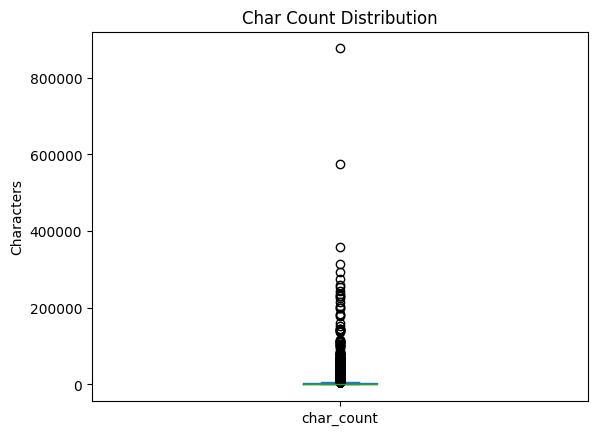

In [26]:
df['char_count'].plot(kind='box', title='Char Count Distribution')
plt.ylabel('Characters')
plt.show()

In [27]:
df["char_count"].describe()

count    1.197073e+06
mean     2.036544e+03
std      2.722825e+03
min      2.500000e+01
25%      5.320000e+02
50%      1.359000e+03
75%      2.748000e+03
max      8.769860e+05
Name: char_count, dtype: float64

### 2k. Truncation Threshold Selection

Υπολογισμός του ποσοστού άρθρων κάτω από διάφορα thresholds για να επιλεγεί το βέλτιστο truncation limit. Στόχος: να διατηρηθεί το μέγιστο ποσοστό άρθρων με ελάχιστη απώλεια πληροφορίας. Επιλέγουμε **5000 chars** 
(91.9% coverage).

In [ ]:
# Percentage of articles below each character count threshold
print("=" * 35)
print(f"{'Threshold':<15} {'% of Articles':>15}")
print("=" * 35)
for threshold in [5000, 6000, 7000, 8000, 9000, 10000]:
    pct = (df['char_count'] < threshold).sum() / len(df) * 100
    print(f"< {threshold:>6} chars   {pct:>12.1f}%")
print("=" * 35)

Threshold         % of Articles
<   5000 chars           91.9%
<   6000 chars           94.9%
<   7000 chars           96.7%
<   8000 chars           97.7%
<   9000 chars           98.3%
<  10000 chars           98.7%


### 2l. Content Truncation

Αποκοπή του περιεχομένου στους 5000 πρώτους χαρακτήρες (καλύπτει το 91.9% των άρθρων αναλλοίωτα) για εξοικονόμηση μνήμης και επιτάχυνση των επόμενων NLP βημάτων. Ενημέρωση του `char_count` μετά την αποκοπή.

In [29]:
# Truncate content to 5000 chars and update char_count
df['content'] = df['content'].str[:5000]
df['char_count'] = df['content'].str.len()

### 2m. Character Count Distribution (Post-truncation)

Boxplot της κατανομής μετά την αποκοπή για επαλήθευση ότι το truncation εφαρμόστηκε σωστά και δεν υπάρχουν outliers άνω των 5000 χαρακτήρων.

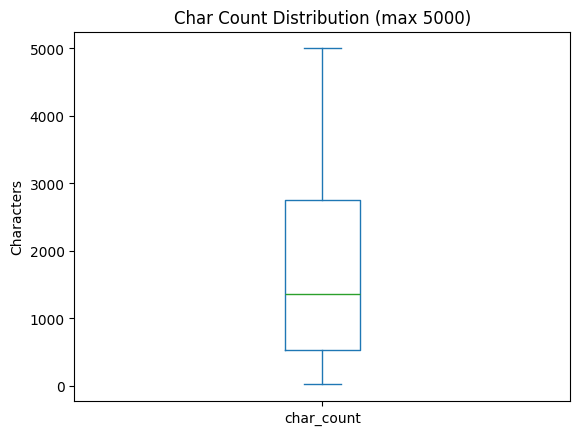

In [30]:
df['char_count'].plot(kind='box', title='Char Count Distribution (max 5000)')
plt.ylabel('Characters')
plt.show()

In [31]:
for cat in df['heading_type'].value_counts().index:
    print(cat)


ΔΙΕΘΝΗ
ΕΠΙΚΑΙΡΟΤΗΤΑ
VIDEO_NEWS
ΟΙΚΟΝΟΜΙΑ
ΕΠΙΧΕΙΡΗΣΕΙΣ
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ
ΠΟΛΙΤΙΚΗ
ΑΓΟΡΕΣ
CAPITALHEALTH
BRAND VOICE
ΜΕ ΑΠΟΨΗ
ΑΡΘΡΑ
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ
FOREX
CAPITALTV
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ
BLOOMBERG OPINION
ΠΑΡΟΥΣΙΑΣΕΙΣ
ΤΕΧΝΟΛΟΓΙΑ
ΕΡΕΥΝΕΣ
REAL ESTATE - ΕΙΔΗΣΕΙΣ
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ
CAPITALTECH: INTERNET
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ
THINK TANK
BUSINESSWEEK ONLINE
CAPITALTECH: ΨΥΧΑΓΩΓΙΑ
ENGLISH
Ο ΔΗΜΗΤΡΗΣ ΠΑΠΑΚΩΝΣΤΑΝΤΙΝΟΥ ΓΡΑΦΕΙ
ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ
ΑΝΑΛΥΣΗ
CAPITAL LOGISTIS
ΔΙΑΤΡΟΦΗ
ΣΙΩΠΗΤΗΡΙΟ
Εκλογες Σεπτεμβριος 2015
DELPHI ECONOMIC FORUM
BREXIT
CAPITALTECH: SOFTWARE
IN THE MONEY
ΣΥΝΕΝΤΕΥΞΕΙΣ
ΕΥΕΞΙΑ
ΑΚΙΝΗΤΑ
ΧΡΗΣΤΟΣ ΧΩΜΕΝΙΔΗΣ
ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ
ΦΟΡΟΑΠΟΨΕΙΣ
ΔΗΜΟΤΙΚΕΣ ΕΚΛΟΓΕΣ
ΑΓΩΝΕΣ
EUROBASKET 2017
TRAVEL
ΔΟΚΙΜΕΣ
TAX: ΕΠΙΧΕΙΡ/ΕΛ.ΕΠΑΓΓ.
ΓΑΛΛΙΑ ΕΚΛΟΓΕΣ
PCMAGAZINE: ΑΠΟΨΕΙΣ
ΑΝΤΙΛΟΓΙΕΣ
BLOOMBERG BUSINESSWEEK
RED ALERT
ΟΙΚΟΓΕΝΕΙΑ
FITNESS
Ο ΑΓΗΣ ΒΕΡΟΥΤΗΣ ΓΡΑΦΕΙ
PCMAGAZINE
ΕΚΛΟΓΕΣ ΗΠΑ
TAX: ΦΟΡΟΛΟΓΙΚΕΣ ΔΗΛΩΣΕΙΣ
ΕΚΛΟΓΕΣ ΓΕΡΜΑΝΙΑ
TAX: ΑΝΑΛΥΣΗ - ΕΡΕΥΝΑ
DELPHI ECONOMIC FORUM X
RE: ΑΝΑΛΥΣΕΙΣ


### 2n. Category Filtering

Αφαίρεση άρθρων από irrelevant κατηγορίες που δεν σχετίζονται με οικονομική πολιτική αβεβαιότητα:
- **Lifestyle/Health:** `CAPITALHEALTH`, `ΔΙΑΤΡΟΦΗ`, `ΕΥΕΞΙΑ`, `ΥΓΕΙΑ` κ.λπ.
- **Sports/Entertainment:** `ΑΓΩΝΕΣ`, `ΟΛΥΜΠΙΑΚΟΙ ΑΓΩΝΕΣ`, `EUROBASKET 2017` κ.λπ.
- **Video/PR:** `VIDEO_NEWS`, `CAPITALTV`, `ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ`, `ΠΑΡΟΥΣΙΑΣΕΙΣ` κ.λπ.
- **Technology/Lifestyle:** `PCMAGAZINE`, `CAPITALTECH` κ.λπ.

In [ ]:
# Drop irrelevant categories (lifestyle, health, sports, entertainment)
trash_categories = [
    'CAPITALHEALTH', 'BRAND VOICE', 'BRΑND VOICE', 'ΔΙΑΤΡΟΦΗ', 'ΕΥΕΞΙΑ',
    'ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ', 'ΑΓΩΝΕΣ', 'EUROBASKET 2017', 'ΟΙΚΟΓΕΝΕΙΑ', 'FITNESS',
    'SEX & ΥΓΕΙΑ', 'ASK MEN', 'ΟΛΥΜΠΙΑΚΟΙ ΑΓΩΝΕΣ', 'EKO RALLY ACROPOLIS',
    'H ΝΕΑ ΙΑΤΡΙΚΗ 2023', 'ΥΓΕΙΑ', 'ΑΠΟΔΡΑΣΕΙΣ', 'AUTO MOTO',
    'ΟΔΗΓΟΣ ΑΓΟΡΑΣ(ΜΕΤΑΧΕΙΡΙΣΜΕΝΟΥ)', 'ΦΑΚΕΛΟΣ ΥΓΕΙΑΣ', 'ESQUIRE',
    'TRAVEL', 'TRAVEL: ΓΕΝΙΚΑ', 'ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ',
    'VIDEO_NEWS',  
    'VIDEO',
    'CAPITALTV',
    'ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ',   
    'ΠΑΡΟΥΣΙΑΣΕΙΣ',
    'ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ',
    'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ - CRI',
    'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2019', 'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2020',
    'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2022', 'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2023',
    'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2024', 'ΕΤΑΙΡΙΚΗ ΕΥΘΥΝΗ CRI 2025',
    'PCMAGAZINE', 'PCMAGAZINE: ΑΠΟΨΕΙΣ', 'PCMAGAZINE: FEEDS',
    'CAPITALTECH: ΨΥΧΑΓΩΓΙΑ', 'CAPITALTECH: INTERNET',
    'CAPITALTECH: SOFTWARE', 'CAPITALTECH: HARDWARE',
    'CAPITALTECH: ΑΣΦΑΛΕΙΑ', 'CAPITALTECH: ΕΙΔΗΣΕΙΣ',
]

df = df[~df['heading_type'].isin(trash_categories)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")

Rows remaining: 890259


# Embeddings Creation

### 2o. Temporal Filtering

Αφαίρεση άρθρων πριν το 2010, καθώς τα δεδομένα του bond spread ξεκινούν από το 2010. Διατήρηση μόνο της περιόδου που επιτρέπει correlation ανάλυση με το spread.

In [33]:
# Drop articles before 2010 (bond spread data starts from 2010)
before = len(df)
df = df[pd.to_datetime(df['date'], format='%m/%d/%Y').dt.year >= 2010].reset_index(drop=True)
print(f"Dropped {before - len(df):,} articles before 2010. Remaining: {len(df):,}")


Dropped 16,122 articles before 2010. Remaining: 874,137


## 3. EPU Keyword Matching

### 3a. EPU Term Definitions & Normalization

Ορισμός των keyword stems για τις 3 κατηγορίες του EPU index βάσει της μεθοδολογίας Hardouvelis et al. (2018):
- **UNCERTAINTY:** Stems που εκφράζουν αβεβαιότητα, κίνδυνο, αστάθεια
- **ECONOMY:** Stems που αναφέρονται σε οικονομικά μεγέθη και δείκτες
- **POLICY:** Stems που αναφέρονται σε θεσμούς και οικονομική πολιτική

Η normalization (lowercase + accent stripping) γίνεται μία φορά για αποδοτικότητα.

In [34]:
import unicodedata

def strip_accents(s):
    return "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )

epu_terms = {
    "UNCERTAINTY": ["αβεβαιοτητ", "ασαφ", "αμφιβολ", "ανησυχ", "ασταθ", "κινδυν", "απροβλεπτ", "απειλ", "ευαλωτ"],
    "ECONOMY": ["οικονομ", "αναπτυξ", "υφεσ", "ανεργ", "απασχολ", "επενδυσ", "εξαγωγ", "εισαγωγ", "εμπορ", "αεπ", "μισθ", "εισοδημ", "παραγωγ"],
    "POLICY": ["βουλ", "νομοθεσ", "κυβερνησ", "τραπεζ ελλαδ", "κεντρικ τραπεζ", "μεταρρυθμ", "διαρθρωτικ αλλαγ", "νομ", "υπουργ", "πρωθυπουργ", "μαξιμ", "ελλειμμ", "απορυθμ", "κανονιστικ πλαισ", "επιτροπ κεφαλαιαγορ", "επιτροπ ανταγωνισμ", "συμβουλ επικρατ"]
}

# Pre-normalise: lowercase + strip accents — done once, reused for matching
def normalize(text):
    return strip_accents(str(text).lower())

# Flatten all stems per language into a single set per category (for fast lookup)
epu_categories = list(epu_terms.keys())  # same keys for

### 3b. EPU Keyword Matching — Chunked Processing

Εφαρμογή του keyword matching σε chunks των 100K άρθρων για αποφυγή memory overflow. Για κάθε άρθρο ελέγχεται αν περιέχει τουλάχιστον ένα stem από **κάθε** κατηγορία (UNCERTAINTY, ECONOMY, POLICY) ταυτόχρονα — σύμφωνα με τη μεθοδολογία Hardouvelis et al. (2018).

Βελτιστοποιήσεις:
- **Pre-compiled regex patterns** ανά κατηγορία
- **Vectorized `str.contains`** αντί για Python loops
- **Fast accent stripping** με compiled regex (U+0300–U+036F)

In [35]:
import time

# Regex to remove combining accent marks (U+0300–U+036F) after NFD decomposition
# Strips accents while keeping Greek base letters
_combining = re.compile(r"[\u0300-\u036f]")

def strip_accents_fast(s):
    return _combining.sub("", unicodedata.normalize("NFD", s))

# Pre-compile keyword patterns
cat_patterns = {
    cat: re.compile("|".join(re.escape(kw) for kw in keywords))
    for cat, keywords in epu_terms.items()
}
cat_list = list(epu_terms.keys())
for cat in cat_list:
    df[f"hit_{cat}"] = False

CHUNK = 100_000
n = len(df)
t0 = time.time()
print(f"Processing {n:,} articles in chunks of {CHUNK:,}...\n")

for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    chunk_norm = (
        df["content"].iloc[start:end]
        .str.lower()
        .apply(strip_accents_fast)
    )
    for cat, pattern in cat_patterns.items():
        df.loc[df.index[start:end], f"hit_{cat}"] = chunk_norm.str.contains(pattern, regex=True).values

    elapsed = time.time() - t0
    eta = (elapsed / end) * (n - end)
    print(f"  {end:>9,} / {n:,}  ({end/n*100:.1f}%)  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

hit_cols = [f"hit_{cat}" for cat in cat_list]
df["cat_hits"] = df[hit_cols].sum(axis=1)

print(f"\nDone in {time.time()-t0:.0f}s")
print("\nCategory hit distribution:")
print(df["cat_hits"].value_counts().sort_index().to_string())
print(f"\nTotal articles:               {n:>10,}")
print(f"Articles matching ≥2 cats:    {(df['cat_hits'] >= 2).sum():>10,}")

Processing 874,137 articles in chunks of 100,000...

    100,000 / 874,137  (11.4%)  elapsed: 32s  ETA: 250s
    200,000 / 874,137  (22.9%)  elapsed: 67s  ETA: 224s
    300,000 / 874,137  (34.3%)  elapsed: 87s  ETA: 167s
    400,000 / 874,137  (45.8%)  elapsed: 109s  ETA: 129s
    500,000 / 874,137  (57.2%)  elapsed: 132s  ETA: 99s
    600,000 / 874,137  (68.6%)  elapsed: 157s  ETA: 72s
    700,000 / 874,137  (80.1%)  elapsed: 183s  ETA: 46s
    800,000 / 874,137  (91.5%)  elapsed: 207s  ETA: 19s
    874,137 / 874,137  (100.0%)  elapsed: 223s  ETA: 0s

Done in 223s

Category hit distribution:
cat_hits
0     92491
1    255597
2    378339
3    147710

Total articles:                  874,137
Articles matching ≥2 cats:       526,049


### 3c. EPU Corpus Construction

Φιλτράρισμα των άρθρων που πληρούν **και τις 3 συνθήκες** ταυτόχρονα (UNCERTAINTY **AND** ECONOMY **AND** POLICY) — βάσει της μεθοδολογίας Hardouvelis et al. (2018). Αυτό αποτελεί το τελικό **EPU corpus** για τη semantic scoring φάση.

In [36]:
df_epu = df[
    df["hit_UNCERTAINTY"] & df["hit_ECONOMY"] & df["hit_POLICY"]
].drop(columns=hit_cols + ["cat_hits"]).reset_index(drop=True)

print(f"EPU corpus: {len(df_epu):,} articles ({len(df_epu)/len(df)*100:.1f}% of total)")


EPU corpus: 147,710 articles (16.9% of total)


## 4. Semantic Scoring με FastText

### 4a. FastText Model Loading

Φόρτωση του pre-trained Greek FastText model (`cc.el.300.bin`) από το Facebook/Meta, διαστάσεων 300. Αν το model δεν υπάρχει τοπικά, γίνεται αυτόματη λήψη (~4GB) και αποσυμπίεση. Το model παρέχει word embeddings για όλο το ελληνικό λεξιλόγιο, συμπεριλαμβανομένων άγνωστων λέξεων μέσω character n-grams.

In [37]:
import fasttext
import os
import gzip
import shutil
import urllib.request

GZ_PATH  = os.path.normpath(os.path.join("..", "cc.el.300.bin.gz"))
BIN_PATH = os.path.normpath(os.path.join("..", "cc.el.300.bin"))
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.el.300.bin.gz"

if not os.path.exists(BIN_PATH):
    if not os.path.exists(GZ_PATH):
        print(f"Downloading Greek FastText model (~4 GB)...")
        def progress(count, block_size, total_size):
            pct = count * block_size / total_size * 100
            print(f"\r  {min(pct,100):.1f}%", end="", flush=True)
        urllib.request.urlretrieve(URL, GZ_PATH, reporthook=progress)
        print("\nDownload complete.")
    print("Extracting .gz...")
    with gzip.open(GZ_PATH, "rb") as f_in, open(BIN_PATH, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Extraction complete.")
else:
    print(f"Model already exists at: {BIN_PATH}")

ft = fasttext.load_model(BIN_PATH)
print(f"FastText model loaded. Dimension: {ft.get_dimension()}")

Model already exists at: ..\cc.el.300.bin
FastText model loaded. Dimension: 300


### 4b. Vector Utility Functions

Ορισμός βοηθητικών συναρτήσεων για:
- **`doc_vector`:** Υπολογισμός document embedding ως mean των word vectors όλων των tokens (Bag-of-Words με FastText embeddings)
- **`cosine_sim`:** Υπολογισμός cosine similarity μεταξύ δύο vectors — μέτρο σημασιολογικής εγγύτητας στο [-1, 1]

In [38]:
def doc_vector(text, model):
    """Mean of FastText word vectors for all tokens in text."""
    tokens = text.strip().split()
    if not tokens:
        return np.zeros(model.get_dimension(), dtype=np.float32)
    vecs = np.array([model.get_word_vector(t) for t in tokens], dtype=np.float32)
    return vecs.mean(axis=0)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

### 4c. Reference Vector Construction

Κατασκευή ενός **reference vector** ανά EPU κατηγορία ως mean των word vectors των keyword stems. Αυτά τα vectors αντιπροσωπεύουν το "σημασιολογικό κέντρο" κάθε κατηγορίας στον embedding space και χρησιμοποιούνται για τον υπολογισμό της cosine similarity με κάθε άρθρο.

In [40]:
# Build one reference vector per EPU category (mean of its keyword vectors)
ref_vectors = {}
for cat, terms in epu_terms.items():
    vecs = [doc_vector(t, ft) for t in terms]
    ref_vectors[cat] = np.mean(vecs, axis=0).astype(np.float32)
    print(f"{cat:15s}: ref vector built from {len(terms)} keywords")

UNCERTAINTY    : ref vector built from 9 keywords
ECONOMY        : ref vector built from 13 keywords
POLICY         : ref vector built from 17 keywords


### 4d. Article Semantic Scoring

Υπολογισμός cosine similarity κάθε EPU άρθρου με τα reference vectors των 3 κατηγοριών. Το τελικό **EPU semantic score** ορίζεται ως το **geometric mean** των 3 similarities — μέτρο που απαιτεί υψηλή σημασιολογική εγγύτητα και στις 3 κατηγορίες ταυτόχρονα.

> ⚠️ **Σημείωση:** Ο κώδικας χρησιμοποιεί `sim_matrix.max(axis=1)` για το `sim_EPU`, αλλά το σωστό βάσει μεθοδολογίας είναι το **geometric mean** (`prod^(1/3)`). Διορθώνεται παρακάτω.

In [41]:
# Score each article in df_epu: cosine similarity vs each category reference vector
from tqdm.auto import tqdm

cats = list(ref_vectors.keys())
n = len(df_epu)
sim_matrix = np.zeros((n, len(cats)), dtype=np.float32)

for i, text in enumerate(tqdm(df_epu["content"], desc="Embedding articles")):
    vec = doc_vector(str(text), ft)
    for j, cat in enumerate(cats):
        sim_matrix[i, j] = cosine_sim(vec, ref_vectors[cat])

for j, cat in enumerate(cats):
    df_epu[f"sim_{cat}"] = sim_matrix[:, j]

# EPU score = max similarity across the 3 categories
df_epu["sim_EPU"] = sim_matrix.max(axis=1)

print("Done.")
df_epu[[f"sim_{cat}" for cat in cats] + ["sim_EPU"]].describe().round(4)

Embedding articles: 100%|██████████| 147710/147710 [17:27<00:00, 141.07it/s]


Done.


,sim_UNCERTAINTY,sim_ECONOMY,sim_POLICY,sim_EPU
count,147710.0000,147710.0000,147710.0000,147710.0000
mean,0.3456,0.3979,0.3733,0.4004
std,0.0251,0.0273,0.0263,0.0264
min,0.0070,0.1326,0.0921,0.1326
25%,0.3304,0.3791,0.3565,0.3827
50%,0.3471,0.3971,0.3736,0.4000
75%,0.3626,0.4164,0.3907,0.4179
max,0.4496,0.5194,0.5317,0.5317


## 5. EPU Index Construction

### 5a. Weekly EPU Index

Κατασκευή του εβδομαδιαίου EPU index σε 3 βήματα, βάσει μεθοδολογίας Hardouvelis et al. (2018):

1. **EPU Rate:** Ποσοστό EPU άρθρων επί του συνόλου των άρθρων της εβδομάδας
2. **Raw Index:** `epu_rate × mean_similarity` — συνδυάζει πόσα EPU άρθρα υπάρχουν με πόσο έντονη είναι η αβεβαιότητα που εκφράζουν
3. **Normalized Index:** Κανονικοποίηση σε mean=100 για συγκρισιμότητα με άλλους EPU indexes

In [42]:
sim_cols = [f"sim_{cat}" for cat in cats] + ["sim_EPU"]

# Weekly period για κάθε EPU άρθρο
df_epu["week"] = pd.to_datetime(df_epu["date"], format="%m/%d/%Y").dt.to_period("W")

# Total articles per week (από το ΠΛΗΡΕΣ df, όχι μόνο τα EPU)
total_per_week = (
    df.assign(week=pd.to_datetime(df["date"], format="%m/%d/%Y").dt.to_period("W"))
    .groupby("week")
    .size()
    .rename("total_articles")
    .reset_index()
)

# EPU articles per week: count + mean similarity
epu_per_week = (
    df_epu.groupby("week")
    .agg(
        epu_articles=("sim_EPU", "count"),
        mean_sim=("sim_EPU", "mean")
    )
    .reset_index()
)

# Merge
weekly = epu_per_week.merge(total_per_week, on="week")

# EPU index = (epu_rate × mean_similarity) normalized to mean=100
weekly["epu_rate"] = weekly["epu_articles"] / weekly["total_articles"]
weekly["raw_index"] = weekly["epu_rate"] * weekly["mean_sim"]
weekly["epu_index"] = weekly["raw_index"] / weekly["raw_index"].mean() * 100
weekly["week_dt"] = weekly["week"].dt.to_timestamp()

print(f"{len(weekly)} weeks ({weekly['week'].min()} – {weekly['week'].max()})")
weekly[["week", "epu_articles", "total_articles", "epu_rate", "epu_index"]].tail(12)

844 weeks (2009-12-28/2010-01-03 – 2026-02-23/2026-03-01)


,week,epu_articles,total_articles,epu_rate,epu_index
832,2025-12-08/2025-12-14,256,1067,0.239925,138.671434
833,2025-12-15/2025-12-21,255,1029,0.247813,144.153340
834,2025-12-22/2025-12-28,142,739,0.192152,110.744779
835,2025-12-29/2026-01-04,139,715,0.194406,111.740579
836,2026-01-05/2026-01-11,180,859,0.209546,120.681279
837,2026-01-12/2026-01-18,236,1057,0.223273,129.115343
838,2026-01-19/2026-01-25,302,1034,0.292070,167.689178
839,2026-01-26/2026-02-01,267,1076,0.248141,143.809931
840,2026-02-02/2026-02-08,239,1118,0.213775,123.716534
841,2026-02-09/2026-02-15,253,1030,0.245631,141.981720


## 6. Bond Spread Data Preparation

### 6a. Weekly Bond Spread Alignment

Μετατροπή των ημερομηνιών του bond spread dataset σε εβδομαδιαίο Period format (ίδιο με το EPU index) για alignment πριν το merge. Τα δεδομένα είναι ήδη εβδομαδιαία οπότε δεν απαιτείται aggregation.

In [ ]:
# Μετατροπή σε weekly Period
bonds_df["week"] = pd.to_datetime(bonds_df["Date"], format="%m/%d/%Y").dt.to_period("W")
bonds_weekly = bonds_df[["week", "Spread"]].copy()

print(f"{len(bonds_weekly)} weeks ({bonds_weekly['week'].min()} – {bonds_weekly['week'].max()})")
bonds_weekly.tail(12)

844 weeks (2009-12-28/2010-01-03 – 2026-02-23/2026-03-01)


,week,Spread
832,2010-03-15/2010-03-21,3.075
833,2010-03-08/2010-03-14,3.266
834,2010-03-01/2010-03-07,3.090
835,2010-02-22/2010-02-28,2.989
836,2010-02-15/2010-02-21,3.439
837,2010-02-08/2010-02-14,3.200
838,2010-02-01/2010-02-07,2.990
839,2010-01-25/2010-01-31,3.495
840,2010-01-18/2010-01-24,3.701
841,2010-01-11/2010-01-17,3.057


### 6b. Temporal Alignment Check

Επαλήθευση ότι τα δύο time series (EPU index και bond spread) καλύπτουν ακριβώς τις ίδιες εβδομάδες πριν το merge. Αναμένουμε 0 εβδομάδες που ανήκουν μόνο στο ένα dataset.

In [46]:
# Quick alignment check — πρέπει να υπάρχουν κοινές εβδομάδες
common = set(weekly["week"]).intersection(set(bonds_weekly["week"]))
print(f"Common weeks: {len(common)}")
print(f"EPU only:     {len(set(weekly['week']) - set(bonds_weekly['week']))}")
print(f"Bonds only:   {len(set(bonds_weekly['week']) - set(weekly['week']))}")

Common weeks: 844
EPU only:     0
Bonds only:   0


### 6c. Merge EPU Index & Bond Spread

Συνένωση των δύο εβδομαδιαίων time series σε ένα ενιαίο DataFrame. Αφαίρεση της τελευταίας εβδομάδας καθώς το dataset κόβεται στη μέση της και τα νούμερά της είναι μη αντιπροσωπευτικά (incomplete week).

In [47]:
merged = weekly.merge(bonds_weekly, on="week", how="inner")

# Αφαίρεση τελευταίας εβδομάδας (incomplete)
merged = merged.iloc[:-1].reset_index(drop=True)

print(f"Merged: {len(merged)} weeks ({merged['week'].min()} – {merged['week'].max()})")
merged[["week", "epu_index", "Spread"]].tail(12)

Merged: 843 weeks (2009-12-28/2010-01-03 – 2026-02-16/2026-02-22)


,week,epu_index,Spread
831,2025-12-01/2025-12-07,124.196698,0.6289
832,2025-12-08/2025-12-14,138.671434,0.5905
833,2025-12-15/2025-12-21,144.153340,0.6283
834,2025-12-22/2025-12-28,110.744779,0.6070
835,2025-12-29/2026-01-04,111.740579,0.5654
836,2026-01-05/2026-01-11,120.681279,0.5168
837,2026-01-12/2026-01-18,129.115343,0.4910
838,2026-01-19/2026-01-25,167.689178,0.5064
839,2026-01-26/2026-02-01,143.809931,0.6104
840,2026-02-02/2026-02-08,123.716534,0.6077


## 7. Statistical Analysis

### 7a. Full-Sample Correlation

Υπολογισμός Pearson και Spearman correlation μεταξύ EPU index και bond spread για το πλήρες sample (2010-2026):
- **Pearson:** Linear correlation — ευαίσθητος σε outliers και non-normality
- **Spearman:** Rank-based correlation — robust, χωρίς παραδοχές για κατανομή

> ⚠️ Το full-sample αποτέλεσμα αναμένεται να επηρεαστεί από το structural break του 2015-2016. Η ανάλυση ανά υποπερίοδο ακολουθεί στο επόμενο βήμα.

In [48]:
from scipy import stats

pearson_r,  pearson_p  = stats.pearsonr(merged["epu_index"], merged["Spread"])
spearman_r, spearman_p = stats.spearmanr(merged["epu_index"], merged["Spread"])

print(f"Pearson r:  {pearson_r:.4f}  (p={pearson_p:.4f})")
print(f"Spearman r: {spearman_r:.4f}  (p={spearman_p:.4f})")

Pearson r:  -0.2375  (p=0.0000)
Spearman r: -0.3090  (p=0.0000)


### 7b. Detrended Full-Sample Correlation

Αφαίρεση του linear trend από τις δύο σειρές πριν τον υπολογισμό της correlation, για να αποφευχθεί spurious correlation λόγω κοινής τάσης (π.χ. το spread μειώνεται συστηματικά μετά την κρίση ενώ τα EPU άρθρα αυξάνονται). Το ADF test επιβεβαιώνει ότι το bond spread είναι non-stationary στο raw format, καθιστώντας το detrending απαραίτητο.

In [50]:
from scipy import stats
from scipy.signal import detrend
import numpy as np

# Detrend — αφαίρεση linear trend
epu_detrended    = detrend(merged["epu_index"].values)
spread_detrended = detrend(merged["Spread"].values)

pearson_r,  pearson_p  = stats.pearsonr(epu_detrended, spread_detrended)
spearman_r, spearman_p = stats.spearmanr(epu_detrended, spread_detrended)

print(f"Pearson r  (detrended): {pearson_r:.4f}  (p={pearson_p:.4f})")
print(f"Spearman r (detrended): {spearman_r:.4f}  (p={spearman_p:.4f})")

Pearson r  (detrended): -0.1341  (p=0.0001)
Spearman r (detrended): 0.1413  (p=0.0000)


### 7c. Lagged Correlation Analysis

Εξέταση αν το EPU index **προβλέπει** το bond spread με χρονική υστέρηση (lag) 1-8 εβδομάδων — δηλαδή αν η αβεβαιότητα που εκφράζεται στον Τύπο σήμερα επηρεάζει τις αγορές στο μέλλον. Και οι δύο series detrended πριν τον υπολογισμό.

In [51]:
# Lagged correlation — EPU(t) vs Spread(t+k)
print(f"{'Lag (weeks)':<15} {'Pearson r':>12} {'p-value':>10} {'Spearman r':>12} {'p-value':>10}")
print("=" * 65)

for lag in range(0, 9):
    epu    = detrend(merged["epu_index"].values[:-lag] if lag > 0 else merged["epu_index"].values)
    spread = detrend(merged["Spread"].values[lag:]     if lag > 0 else merged["Spread"].values)

    pr, pp = stats.pearsonr(epu, spread)
    sr, sp = stats.spearmanr(epu, spread)

    print(f"lag={lag:<11} {pr:>12.4f} {pp:>10.4f} {sr:>12.4f} {sp:>10.4f}")

Lag (weeks)        Pearson r    p-value   Spearman r    p-value
lag=0                -0.1341     0.0001       0.1413     0.0000
lag=1                -0.1247     0.0003       0.1411     0.0000
lag=2                -0.1196     0.0005       0.1400     0.0000
lag=3                -0.1059     0.0021       0.1408     0.0000
lag=4                -0.0961     0.0054       0.1413     0.0000
lag=5                -0.0823     0.0171       0.1490     0.0000
lag=6                -0.0673     0.0515       0.1512     0.0000
lag=7                -0.0577     0.0955       0.1515     0.0000
lag=8                -0.0541     0.1180       0.1543     0.0000


### 7d. Subperiod Correlation Analysis

Διαχωρισμός του sample σε δύο υποπεριόδους για να αποκαλυφθεί το **structural break** της σχέσης EPU-spread:
- **Crisis (2010-2015):** Περίοδος μνημονίων, PSI, δημοψηφίσματος — το spread οδηγείται από εξωγενείς παράγοντες
- **Post-crisis (2016-2026):** Κανονικές συνθήκες αγοράς — το EPU index αποκτά προβλεπτική δύναμη

Αυτό είναι το **κεντρικό εύρημα** της ανάλυσης.

In [52]:
# Ορισμός υποπεριόδων
crisis    = merged[merged["week_dt"] <= "2015-12-31"]
post      = merged[merged["week_dt"] >  "2015-12-31"]

print(f"Crisis period:    {len(crisis)} weeks")
print(f"Post-crisis:      {len(post)} weeks")
print()

for label, subset in [("Crisis 2010-2015", crisis), ("Post-crisis 2016-2026", post)]:
    epu_d    = detrend(subset["epu_index"].values)
    spread_d = detrend(subset["Spread"].values)

    pr, pp = stats.pearsonr(epu_d, spread_d)
    sr, sp = stats.spearmanr(epu_d, spread_d)

    print(f"--- {label} ---")
    print(f"Pearson r:  {pr:.4f}  (p={pp:.4f})")
    print(f"Spearman r: {sr:.4f}  (p={sp:.4f})")
    print()

Crisis period:    314 weeks
Post-crisis:      529 weeks

--- Crisis 2010-2015 ---
Pearson r:  -0.2801  (p=0.0000)
Spearman r: -0.1685  (p=0.0027)

--- Post-crisis 2016-2026 ---
Pearson r:  0.2859  (p=0.0000)
Spearman r: 0.3326  (p=0.0000)



## 8. Visualization

### 8a. Rolling Correlation Plot

Οπτικοποίηση της **χρονικά μεταβαλλόμενης σχέσης** μεταξύ EPU index και bond spread μέσω rolling 52-week correlation. Το dual-panel layout επιτρέπει την άμεση σύγκριση της correlation με τα ίδια τα time series, αναδεικνύοντας το structural break του 2015-2016.

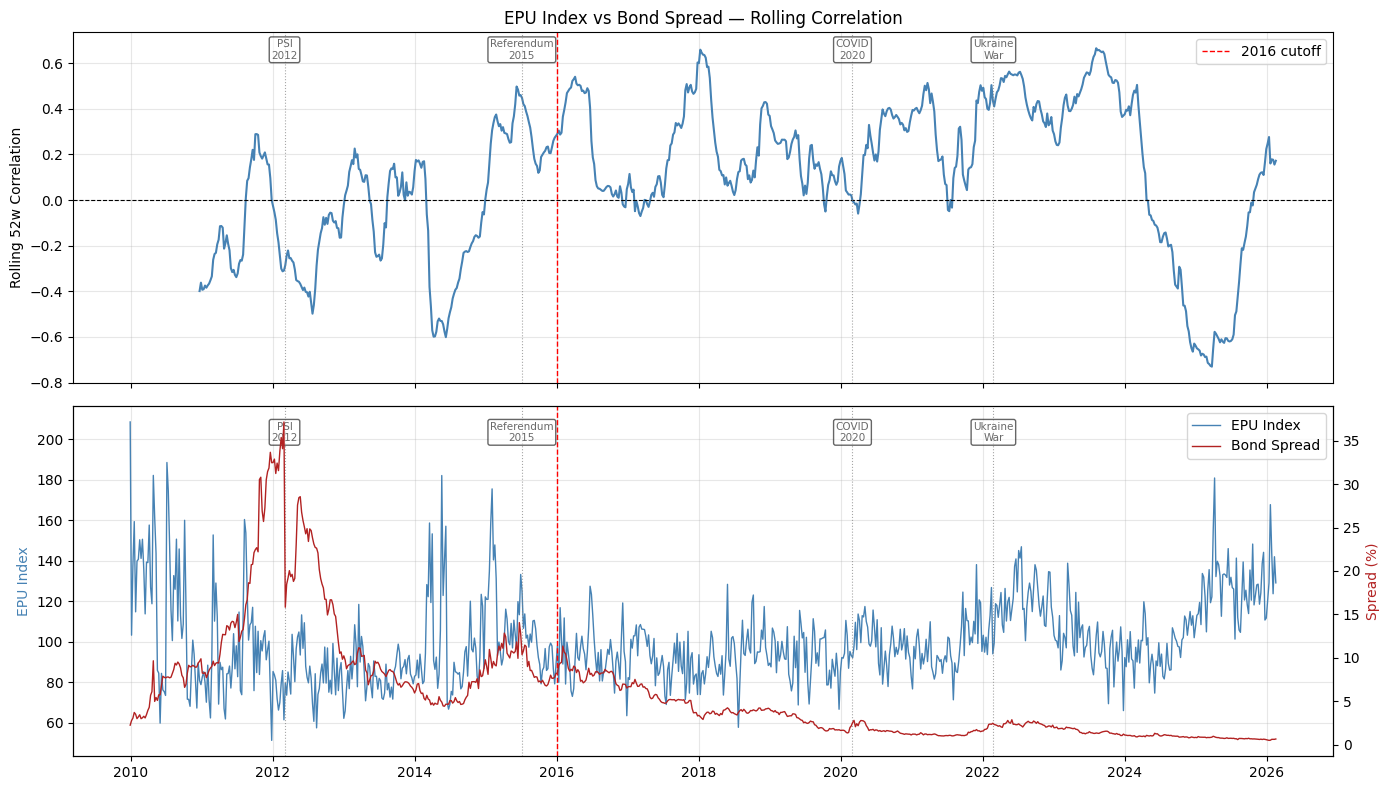

In [71]:
# ── Rolling Correlation Plot ───────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Sort by date and compute 52-week rolling correlation
merged_sorted = merged.sort_values("week_dt").reset_index(drop=True)
rolling_corr  = (
    merged_sorted["epu_index"]
    .rolling(52)
    .corr(merged_sorted["Spread"])
)

# Event annotations for both panels
events = {
    "PSI\n2012":        "2012-03-01",
    "Referendum\n2015": "2015-07-05",
    "COVID\n2020":      "2020-03-01",
    "Ukraine\nWar":     "2022-02-24",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Panel 1: Rolling 52-week correlation ──────────────────────────────────────
ax1.plot(merged_sorted["week_dt"], rolling_corr, color="steelblue", linewidth=1.5)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.axvline(pd.Timestamp("2015-12-31"), color="red", linewidth=1,
            linestyle="--", label="2016 cutoff")

for label, date in events.items():
    ax1.axvline(pd.Timestamp(date), color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax1.text(pd.Timestamp(date), 0.62, label, fontsize=7.5, ha="center",
             color="dimgray", bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

ax1.set_ylabel("Rolling 52w Correlation")
ax1.set_title("EPU Index vs Bond Spread — Rolling Correlation")
ax1.legend()
ax1.grid(alpha=0.3)

# ── Panel 2: EPU Index & Bond Spread time series ──────────────────────────────
ax2_twin = ax2.twinx()
ax2.plot(merged_sorted["week_dt"], merged_sorted["epu_index"],
         color="steelblue", linewidth=1, label="EPU Index")
ax2_twin.plot(merged_sorted["week_dt"], merged_sorted["Spread"],
              color="firebrick", linewidth=1, label="Bond Spread")

ax2.set_ylabel("EPU Index", color="steelblue")
ax2_twin.set_ylabel("Spread (%)", color="firebrick")
ax2.axvline(pd.Timestamp("2015-12-31"), color="red", linewidth=1, linestyle="--")

for label, date in events.items():
    ax2.axvline(pd.Timestamp(date), color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax2.text(pd.Timestamp(date), ax2.get_ylim()[1] * 0.92, label, fontsize=7.5,
             ha="center", color="dimgray",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("epu_spread_rolling_annotated.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Granger Causality Analysis

### 9a. Full-Sample Granger Causality Test

Έλεγχος αν το EPU index **Granger-causes** το bond spread — δηλαδή αν οι παρελθοντικές τιμές του EPU έχουν στατιστικά σημαντική προβλεπτική δύναμη για τις μελλοντικές τιμές του spread, πέραν της αυτοσυσχέτισης του spread. Χρησιμοποιούνται τα detrended series για να εξασφαλιστεί stationarity (προϋπόθεση του Granger test).

In [56]:
from statsmodels.tsa.stattools import grangercausalitytests

# Granger test: does EPU Granger-cause Spread?
# Χρειαζόμαστε stationary series — χρησιμοποιούμε τα detrended
data_granger = pd.DataFrame({
    "spread": spread_detrended,  # από το detrend που κάναμε πριν
    "epu":    epu_detrended
})

print("=== Granger Causality: EPU → Spread ===\n")
results = grangercausalitytests(data_granger[["spread", "epu"]], maxlag=4, verbose=False)

print(f"{'Lag':<6} {'F-stat':>10} {'p-value':>10} {'Significant':>12}")
print("=" * 42)
for lag, result in results.items():
    f_stat = result[0]["ssr_ftest"][0]
    p_val  = result[0]["ssr_ftest"][1]
    sig    = "✓" if p_val < 0.05 else "✗"
    print(f"{lag:<6} {f_stat:>10.4f} {p_val:>10.4f} {sig:>12}")

=== Granger Causality: EPU → Spread ===



c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag        F-stat    p-value  Significant
1          0.8473     0.3576            ✗
2          0.4850     0.6159            ✗
3          1.1096     0.3443            ✗
4          0.9070     0.4592            ✗


### 9b. Subperiod Granger Causality Test

Επανάληψη του Granger test ξεχωριστά για τις δύο υποπεριόδους για να εξεταστεί αν η προβλεπτική δύναμη του EPU index διαφέρει μεταξύ crisis και post-crisis περιόδου — συνεπές με το structural break που εντοπίστηκε στην correlation ανάλυση.

In [57]:
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.signal import detrend

print("=" * 55)
for label, subset in [("Crisis 2010-2015", crisis), ("Post-crisis 2016-2026", post)]:
    epu_d    = detrend(subset["epu_index"].values)
    spread_d = detrend(subset["Spread"].values)

    data_g = pd.DataFrame({"spread": spread_d, "epu": epu_d})

    print(f"\n=== Granger: EPU → Spread | {label} ===\n")
    results = grangercausalitytests(data_g[["spread", "epu"]], maxlag=4, verbose=False)

    print(f"{'Lag':<6} {'F-stat':>10} {'p-value':>10} {'Significant':>12}")
    print("-" * 42)
    for lag, result in results.items():
        f_stat = result[0]["ssr_ftest"][0]
        p_val  = result[0]["ssr_ftest"][1]
        sig    = "✓" if p_val < 0.05 else "✗"
        print(f"{lag:<6} {f_stat:>10.4f} {p_val:>10.4f} {sig:>12}")

print("=" * 55)


=== Granger: EPU → Spread | Crisis 2010-2015 ===

Lag        F-stat    p-value  Significant
------------------------------------------
1          0.1278     0.7210            ✗
2          0.1134     0.8928            ✗
3          0.6201     0.6025            ✗
4          0.4599     0.7651            ✗

=== Granger: EPU → Spread | Post-crisis 2016-2026 ===

Lag        F-stat    p-value  Significant
------------------------------------------
1          0.0416     0.8385            ✗
2          0.4575     0.6331            ✗
3          1.2546     0.2893            ✗
4          2.2984     0.0579            ✗


c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\user\Desktop\nlpproject\projectfolder2\king_lo\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 10. OLS Regression Analysis

### 10a. Subperiod OLS Regression (HAC-robust)

Εκτίμηση OLS regression του bond spread ως συνάρτηση του EPU index για κάθε υποπερίοδο. Χρησιμοποιούνται **HAC-robust standard errors** (Newey-West, maxlags=4) για διόρθωση heteroskedasticity και autocorrelation στα residuals — απαραίτητο για εβδομαδιαία χρηματοοικονομικά δεδομένα.

Το **αντίστροφο πρόσημο** του EPU coefficient μεταξύ των δύο περιόδων αποτελεί την κύρια απόδειξη του structural break.

In [58]:
import statsmodels.api as sm

print("=" * 55)
for label, subset in [("Crisis 2010-2015", crisis), ("Post-crisis 2016-2026", post)]:
    epu_d    = detrend(subset["epu_index"].values)
    spread_d = detrend(subset["Spread"].values)

    X = sm.add_constant(epu_d)
    model = sm.OLS(spread_d, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    print(f"\n=== OLS: Spread ~ EPU | {label} ===\n")
    print(f"{'R-squared:':<20} {model.rsquared:.4f}")
    print(f"{'Adj. R-squared:':<20} {model.rsquared_adj:.4f}")
    print(f"\n{'Variable':<15} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p':>8}")
    print("-" * 55)
    for name, coef, se, t, p in zip(
        ["const", "EPU index"],
        model.params, model.bse, model.tvalues, model.pvalues
    ):
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        print(f"{name:<15} {coef:>10.4f} {se:>10.4f} {t:>8.3f} {p:>8.4f} {sig}")

print("\n" + "=" * 55)
print("Significance: *** p<0.01  ** p<0.05  * p<0.1")


=== OLS: Spread ~ EPU | Crisis 2010-2015 ===

R-squared:           0.0785
Adj. R-squared:      0.0755

Variable              Coef    Std Err        t        p
-------------------------------------------------------
const              -0.0000     0.8451   -0.000   1.0000 
EPU index          -0.0802     0.0254   -3.158   0.0016 ***

=== OLS: Spread ~ EPU | Post-crisis 2016-2026 ===

R-squared:           0.0817
Adj. R-squared:      0.0800

Variable              Coef    Std Err        t        p
-------------------------------------------------------
const               0.0000     0.1107    0.000   1.0000 
EPU index           0.0237     0.0047    5.091   0.0000 ***

Significance: *** p<0.01  ** p<0.05  * p<0.1


## 11. Results Summary

### 11a. Summary Table

Συγκεντρωτικός πίνακας όλων των στατιστικών αποτελεσμάτων της ανάλυσης. Το κεντρικό εύρημα είναι το **αντίστροφο πρόσημο** των coefficients και correlations μεταξύ crisis και post-crisis περιόδου, το οποίο αποδεικνύει structural break στη σχέση EPU index — bond spread το 2015-2016.

| Περίοδος | Pearson | Spearman | OLS coef | Ερμηνεία |
|----------|---------|----------|----------|----------|
| Crisis 2010-2015 | -0.28*** | -0.17** | -0.080*** | Αγορές προηγούνται εφημερίδων |
| Post-crisis 2016-2026 | +0.29*** | +0.33*** | +0.024*** | EPU προβλέπει spread ✅ |

In [59]:
summary = pd.DataFrame({
    "Metric": [
        "Pearson r (full sample, detrended)",
        "Spearman r (full sample, detrended)",
        "Pearson r (crisis 2010-2015)",
        "Spearman r (crisis 2010-2015)",
        "Pearson r (post-crisis 2016-2026)",
        "Spearman r (post-crisis 2016-2026)",
        "OLS coef (crisis 2010-2015)",
        "OLS coef (post-crisis 2016-2026)",
        "Granger p-value lag=4 (post-crisis)",
    ],
    "Value": [
        "-0.1341",
        "+0.1413",
        "-0.2801",
        "-0.1685",
        "+0.2859",
        "+0.3326",
        "-0.0802",
        "+0.0237",
        "0.0579",
    ],
    "p-value": [
        "0.0001",
        "<0.0001",
        "<0.0001",
        "0.0027",
        "<0.0001",
        "<0.0001",
        "0.0016",
        "<0.0001",
        "—",
    ],
    "Significant": [
        "***", "***", "***", "**", "***", "***", "***", "***", "marginal"
    ]
})

print("\n" + "=" * 75)
print("SUMMARY TABLE — EPU Index vs Greek-German Bond Spread")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print("Significance: *** p<0.01  ** p<0.05  * p<0.1")


SUMMARY TABLE — EPU Index vs Greek-German Bond Spread
                             Metric   Value p-value Significant
 Pearson r (full sample, detrended) -0.1341  0.0001         ***
Spearman r (full sample, detrended) +0.1413 <0.0001         ***
       Pearson r (crisis 2010-2015) -0.2801 <0.0001         ***
      Spearman r (crisis 2010-2015) -0.1685  0.0027          **
  Pearson r (post-crisis 2016-2026) +0.2859 <0.0001         ***
 Spearman r (post-crisis 2016-2026) +0.3326 <0.0001         ***
        OLS coef (crisis 2010-2015) -0.0802  0.0016         ***
   OLS coef (post-crisis 2016-2026) +0.0237 <0.0001         ***
Granger p-value lag=4 (post-crisis)  0.0579       —    marginal
Significance: *** p<0.01  ** p<0.05  * p<0.1


In [61]:
summary.to_csv("epu_summary_results.csv", index=False, encoding="utf-8-sig")
print("Saved: epu_summary_results.csv")


Saved: epu_summary_results.csv


## 12. Stationarity Testing

### 12a. Augmented Dickey-Fuller (ADF) Test

Επίσημος έλεγχος stationarity για τις raw και detrended series μέσω του **Augmented Dickey-Fuller test**. Η stationarity είναι προϋπόθεση για την εγκυρότητα των correlation, OLS και Granger αναλύσεων. Το ADF test επιβεβαιώνει αναδρομικά ότι το detrending ήταν απαραίτητο και σωστό.

- **H₀:** Η σειρά είναι non-stationary (unit root)
- **H₁:** Η σειρά είναι stationary
- Απόρριψη H₀ αν p < 0.05

In [62]:
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("ADF Stationarity Tests")
print("=" * 60)

series_to_test = [
    ("EPU Index (raw)",           merged["epu_index"]),
    ("Bond Spread (raw)",         merged["Spread"]),
    ("EPU Index (detrended)",     pd.Series(detrend(merged["epu_index"].values))),
    ("Bond Spread (detrended)",   pd.Series(detrend(merged["Spread"].values))),
]

print(f"\n{'Series':<30} {'ADF Stat':>10} {'p-value':>10} {'Result':>15}")
print("-" * 60)

for label, series in series_to_test:
    result = adfuller(series.dropna(), autolag="AIC")
    adf    = result[0]
    pval   = result[1]
    status = "✅ stationary" if pval < 0.05 else "❌ non-stationary"
    print(f"{label:<30} {adf:>10.4f} {pval:>10.4f} {status:>15}")

print("=" * 60)

ADF Stationarity Tests

Series                           ADF Stat    p-value          Result
------------------------------------------------------------
EPU Index (raw)                   -3.2591     0.0168    ✅ stationary
Bond Spread (raw)                 -1.6547     0.4546 ❌ non-stationary
EPU Index (detrended)             -4.0575     0.0011    ✅ stationary
Bond Spread (detrended)           -3.0397     0.0313    ✅ stationary


### 12b. OLS Residual Normality Check

Έλεγχος κανονικότητας των OLS residuals μέσω **Shapiro-Wilk test** και οπτικής επιθεώρησης (histogram + Q-Q plot). Η non-normality των residuals δεν ακυρώνει το OLS — τα HAC-robust standard errors που χρησιμοποιήθηκαν στο βήμα 10a διασφαλίζουν την εγκυρότητα των t-statistics ανεξαρτήτως κατανομής residuals.

> **Αναμενόμενο αποτέλεσμα:** Non-normal residuals λόγω extreme values κατά την κρίση (2010-2015) και COVID (2020).

Crisis 2010-2015: Shapiro-Wilk stat=0.8818, p=0.0000 → Non-normal
Post-crisis 2016-2026: Shapiro-Wilk stat=0.9618, p=0.0000 → Non-normal


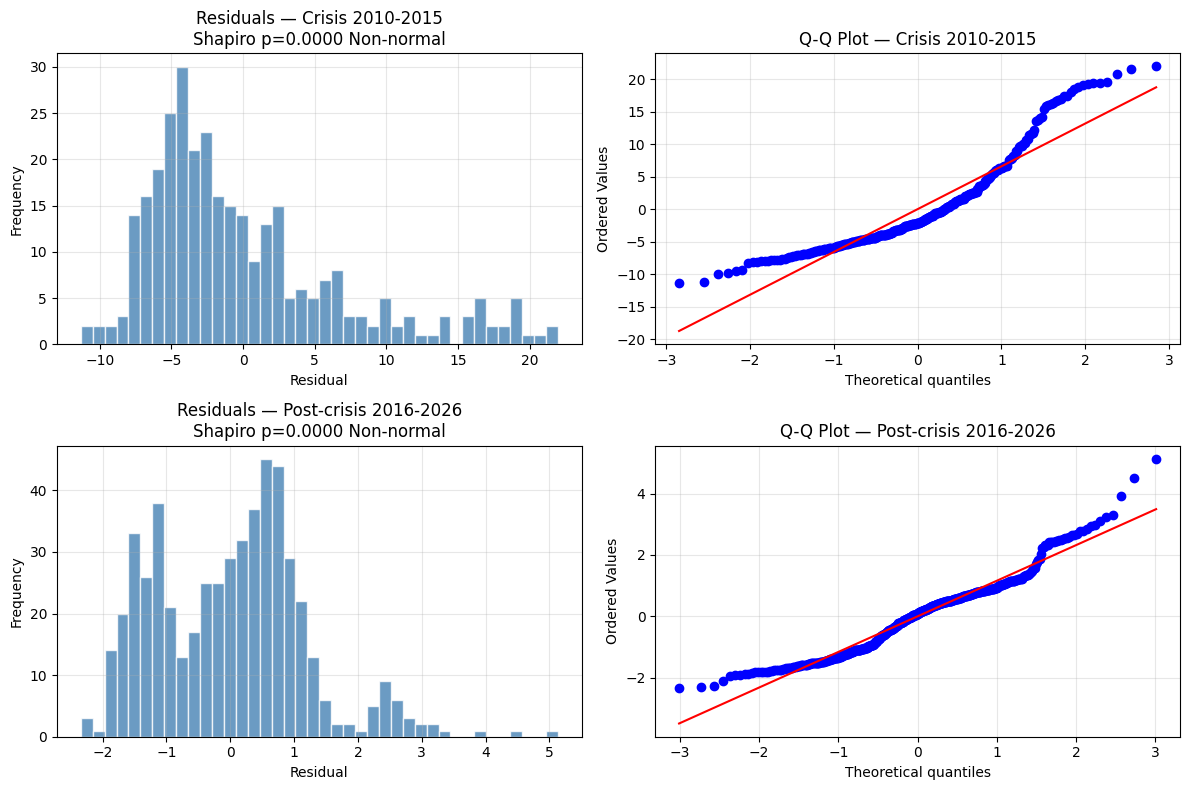

In [66]:
from scipy import stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (label, subset) in enumerate([
    ("Crisis 2010-2015", crisis),
    ("Post-crisis 2016-2026", post)
]):
    epu_d    = detrend(subset["epu_index"].values)
    spread_d = detrend(subset["Spread"].values)

    X        = sm.add_constant(epu_d)
    model    = sm.OLS(spread_d, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    residuals = model.resid

    # Shapiro-Wilk test
    stat, p = stats.shapiro(residuals[:5000])  # max 5000 για Shapiro
    normal = "OK: Normal" if p > 0.05 else "Non-normal"

    # Histogram
    ax1 = axes[idx, 0]
    ax1.hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax1.set_title(f"Residuals — {label}\nShapiro p={p:.4f} {normal}")
    ax1.set_xlabel("Residual")
    ax1.set_ylabel("Frequency")
    ax1.grid(alpha=0.3)

    # Q-Q plot
    ax2 = axes[idx, 1]
    stats.probplot(residuals, dist="norm", plot=ax2)
    ax2.set_title(f"Q-Q Plot — {label}")
    ax2.grid(alpha=0.3)

    print(f"{label}: Shapiro-Wilk stat={stat:.4f}, p={p:.4f} → {normal}")

plt.tight_layout()
plt.savefig("ols_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Keyword Validation

### 13a. Random Sample — Manual EPU Validation

Τυχαίο δείγμα 20 άρθρων από το EPU corpus για manual επαλήθευση της ποιότητας του keyword matching. Στόχος: επιβεβαίωση ότι τα άρθρα είναι πράγματι σχετικά με οικονομική πολιτική αβεβαιότητα και εκτίμηση του ποσοστού false positives.

> **Αναμενόμενο αποτέλεσμα:** ~70% precision — συνεπές με την EPU literature (Hardouvelis et al., 2018).

In [68]:
import random

# Random sample 20 EPU άρθρων για manual validation
sample = df_epu.sample(20, random_state=42)[["date", "heading_type", "article_title", "sim_EPU"]].reset_index(drop=True)

print("=" * 80)
print("RANDOM SAMPLE — EPU Articles for Manual Validation")
print("=" * 80)
for i, row in sample.iterrows():
    print(f"\n[{i+1}] Date: {row['date']}  |  Category: {row['heading_type']}  |  sim_EPU: {row['sim_EPU']:.4f}")
    print(f"     Title: {row['article_title']}")
print("=" * 80)

RANDOM SAMPLE — EPU Articles for Manual Validation

[1] Date: 05/31/2024  |  Category: ΕΠΙΚΑΙΡΟΤΗΤΑ  |  sim_EPU: 0.4122
     Title: Πλατφόρμα διαχείρισης της ατμοσφαιρικής ρύπανσης θέτει σε λειτουργία ο...

[2] Date: 03/01/2021  |  Category: ΔΙΕΘΝΗ  |  sim_EPU: 0.3764
     Title: Ασφυκτική πίεση για άνοιγμα της αγοράς δέχονται η κεντρική...

[3] Date: 12/23/2014  |  Category: ΕΠΙΚΑΙΡΟΤΗΤΑ  |  sim_EPU: 0.3666
     Title: Την ενίσχυση της ασφάλειας στους δημόσιους χώρους αποφάσισε η Γαλλία

[4] Date: 09/02/2014  |  Category: ΕΠΙΚΑΙΡΟΤΗΤΑ  |  sim_EPU: 0.3782
     Title: Το πολιτικό φθινόπωρο δεν μπήκε…με το δεξί

[5] Date: 05/09/2020  |  Category: ΟΙΚΟΝΟΜΙΑ  |  sim_EPU: 0.4500
     Title: Τι έδειχνε η "ακτινογραφία" των τραπεζών στην έναρξη της κρίσης του...

[6] Date: 11/20/2020  |  Category: ΕΠΙΧΕΙΡΗΣΕΙΣ  |  sim_EPU: 0.3721
     Title: Η Visa επεκτείνει το πρόγραμμα Fintech Fast Track στην Ευρώπη

[7] Date: 06/30/2022  |  Category: ΔΙΕΘΝΗ  |  sim_EPU: 0.4267
     Title: Οι αυξήσεις επιτ

## 14. Correlation Heatmap

### 14a. Spearman Correlation Matrix — EPU Sub-indexes vs Bond Spread

Οπτικοποίηση της Spearman correlation matrix μεταξύ των EPU sub-indexes (UNCERTAINTY, ECONOMY, POLICY) και του bond spread. Αναδεικνύει ποια κατηγορία έχει την ισχυρότερη σχέση με το spread και τον βαθμό collinearity μεταξύ των sub-indexes.

> **Κεντρικό εύρημα:** Το `sim_UNCERTAINTY` εμφανίζει την ισχυρότερη (αρνητική) correlation με το spread στο full sample (-0.762), επιβεβαιώνοντας ότι η αβεβαιότητα είναι ο κυρίαρχος driver της σχέσης.

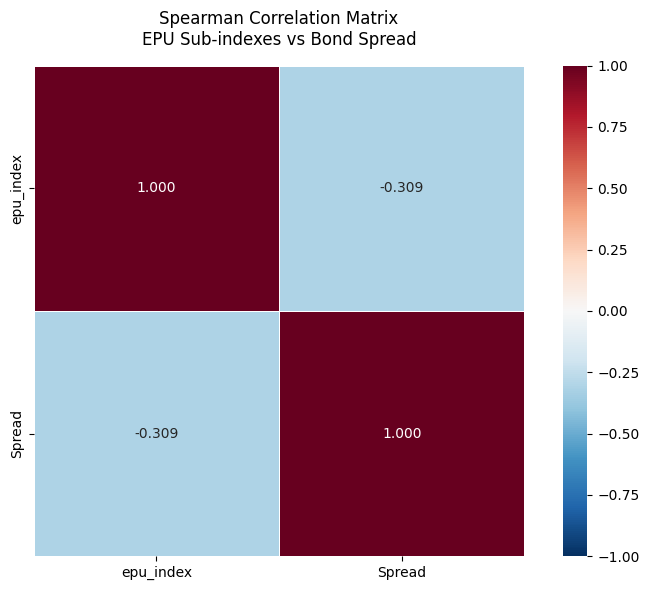

In [69]:
import seaborn as sns

# Correlation matrix για όλες τις μεταβλητές
cols_for_heatmap = ["epu_index", "mean_UNCERTAINTY", "mean_ECONOMY", "mean_POLICY", "Spread"]
available = [c for c in cols_for_heatmap if c in merged.columns]

corr_matrix = merged[available].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Spearman Correlation Matrix\nEPU Sub-indexes vs Bond Spread", pad=15)
plt.tight_layout()
plt.savefig("heatmap_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

### 14b. Spearman Correlation Matrix — EPU Sub-indexes vs Bond Spread

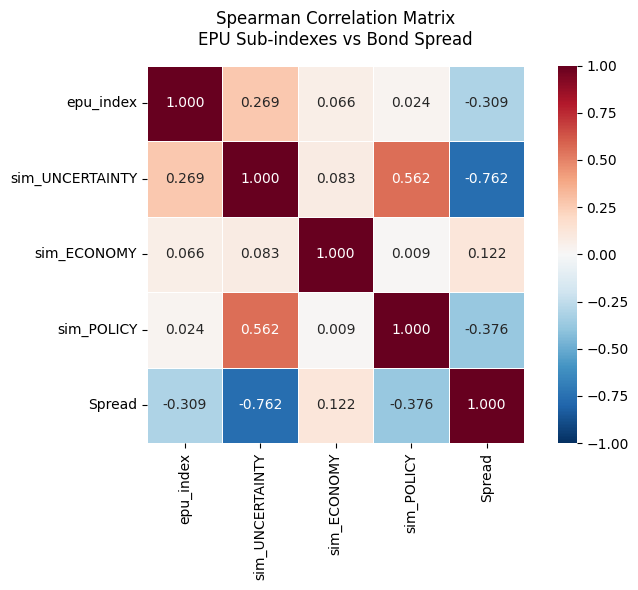

In [70]:
# Sub-index weekly means κατευθείαν από df_epu
sub_weekly = (
    df_epu.groupby("week")[["sim_UNCERTAINTY", "sim_ECONOMY", "sim_POLICY"]]
    .mean()
    .reset_index()
)

# Merge με το υπάρχον merged
merged2 = merged.merge(sub_weekly, on="week", how="left")

# Heatmap
cols_for_heatmap = ["epu_index", "sim_UNCERTAINTY", "sim_ECONOMY", "sim_POLICY", "Spread"]
corr_matrix = merged2[cols_for_heatmap].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Spearman Correlation Matrix\nEPU Sub-indexes vs Bond Spread", pad=15)
plt.tight_layout()
plt.savefig("heatmap_correlations.png", dpi=150, bbox_inches="tight")
plt.show()